# Store Item Demand Forecasting — Single-Series Time Series Modeling

Time series forecasting project on the [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview) dataset (Kaggle) — 5 years of daily sales for 50 items across 10 stores. Rather than modeling all 500 store-item pairs, the assignment focuses on a single series (Store 1, Item 1) to compare baseline, statistical, and machine learning forecasting approaches end-to-end, evaluated with MAPE, before discussing how the winning approach would scale to the full dataset.

**1. Loading the Data**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/ML/time_series'  # adjust if the project folder is stored elsewhere on Drive
!ls {path}

Mounted at /content/drive
data  models  notebook	reports


In [2]:
import os

os.makedirs(f'{path}/models', exist_ok=True)
os.makedirs(f'{path}/reports', exist_ok=True)

In [3]:
import pandas as pd

Loading the data:

In [4]:
data = pd.read_csv(f'{path}/data/train.csv')
display(data.head(10))

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10
5,2013-01-06,1,1,12
6,2013-01-07,1,1,10
7,2013-01-08,1,1,9
8,2013-01-09,1,1,12
9,2013-01-10,1,1,9


Converting the `date` column to `datetime` format and setting it as the dataframe index.

In [5]:
data['date']=pd.to_datetime(data['date'])

In [6]:
data.set_index('date', inplace=True)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


Checking the dates:

In [8]:
data.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2017-12-22', '2017-12-23', '2017-12-24', '2017-12-25',
               '2017-12-26', '2017-12-27', '2017-12-28', '2017-12-29',
               '2017-12-30', '2017-12-31'],
              dtype='datetime64[ns]', name='date', length=913000, freq=None)

**2. Exploratory Data Analysis**

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Plot 1: Sales dynamics by item, with confidence band ---
item_stats = data.groupby(['date', 'item'])['sales'].agg(['mean', 'std']).reset_index()
item_stats

,date,item,mean,std
0,2013-01-01,1,13.3,4.056545
1,2013-01-01,2,32.7,7.071853
2,2013-01-01,3,17.2,4.756282
3,2013-01-01,4,10.2,4.732864
4,2013-01-01,5,8.3,3.056868
...,...,...,...,...
91295,2017-12-31,46,60.5,16.534476
91296,2017-12-31,47,21.1,5.685264
91297,2017-12-31,48,49.4,11.805837
91298,2017-12-31,49,28.5,10.596121


First, let's look at the dynamics over the full period for a few items:

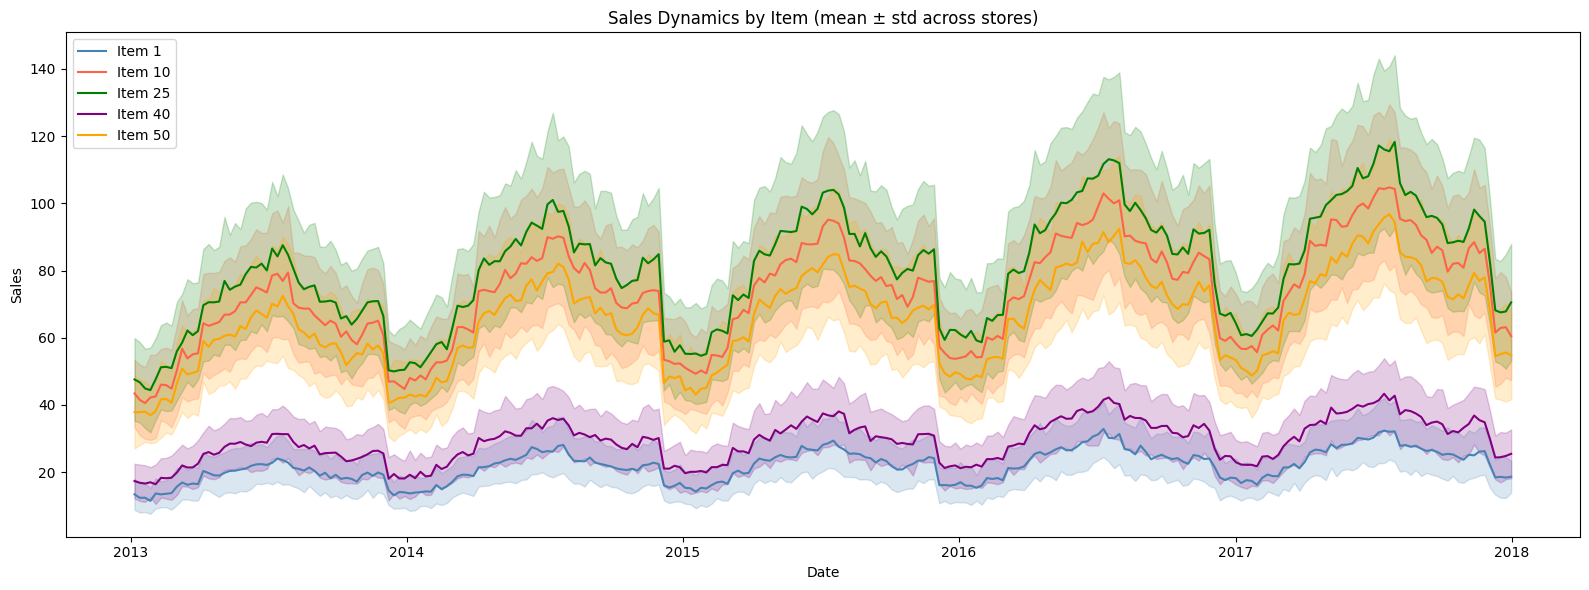

In [10]:


fig, ax = plt.subplots(figsize=(16, 6))

colors = ['steelblue', 'tomato', 'green', 'purple', 'orange']
selected_items = [1, 10, 25, 40, 50]

for item_id, color in zip(selected_items, colors):
    subset = item_stats[item_stats['item'] == item_id].set_index('date').resample('W').mean()

    ax.plot(subset.index, subset['mean'], label=f'Item {item_id}', color=color)
    ax.fill_between(
        subset.index,
        subset['mean'] - subset['std'],
        subset['mean'] + subset['std'],
        alpha=0.2,
        color=color
    )

ax.set_title('Sales Dynamics by Item (mean ± std across stores)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.savefig(f'{path}/reports/item_dynamics_confidence_band.png', dpi=150, bbox_inches='tight')
plt.show()


From the plot, we can see that:

- all items show a clear upward trend from 2013 to 2018
- a clear annual seasonality is visible — peaks in summer (mid-year), dips in winter
- items differ significantly in sales level: Item 25 (green) is the highest, Item 40 (purple) is the lowest — but the shape is similar for all, just at different levels

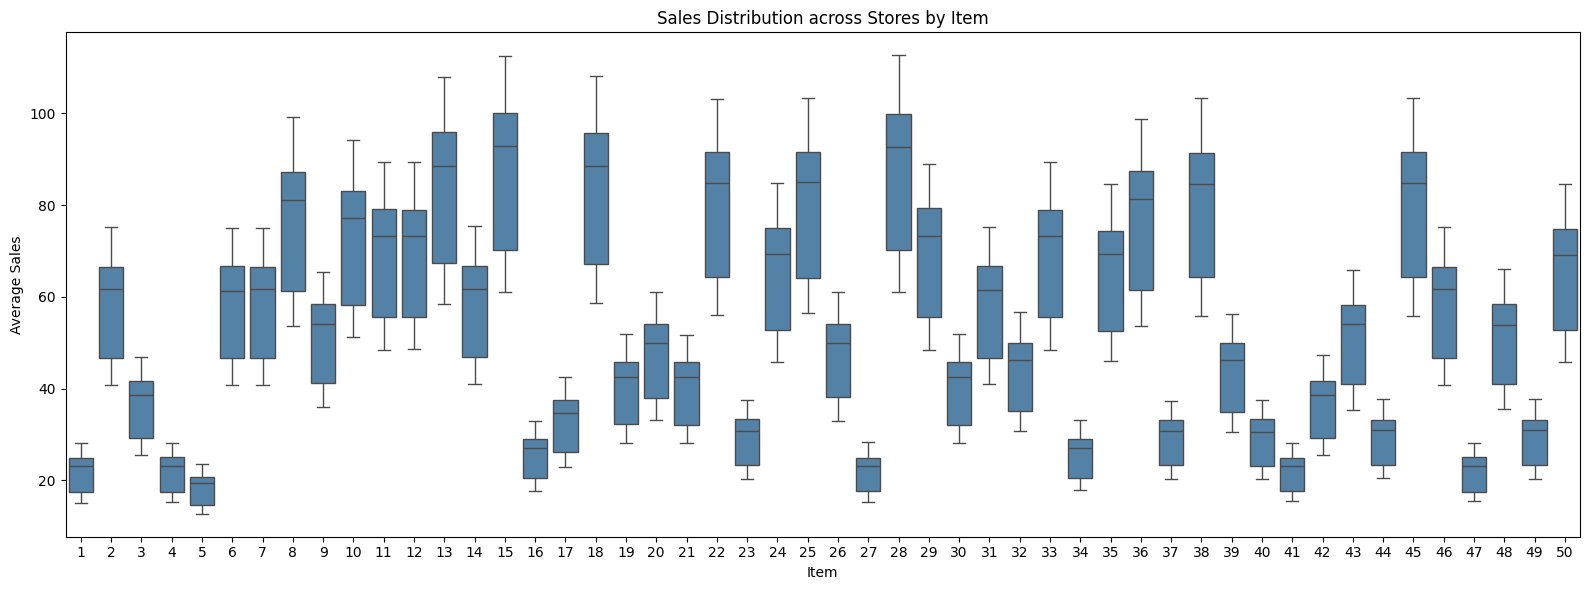

In [11]:
# --- Plot 2: Boxplot — sales distribution across stores, by item ---
monthly = data.reset_index()
monthly['month'] = monthly['date'].dt.to_period('M')
item_store = monthly.groupby(['store', 'item'])['sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))
sns.boxplot(data=item_store, x='item', y='sales', ax=ax, color='steelblue', fliersize=3)
ax.set_title('Sales Distribution across Stores by Item')
ax.set_xlabel('Item')
ax.set_ylabel('Average Sales')
plt.tight_layout()
plt.savefig(f'{path}/reports/boxplot_sales_by_store_item.png', dpi=150, bbox_inches='tight')
plt.show()

This plot (2) shows that items differ a lot in sales level — some consistently sell around ~20, others reach ~100. This confirms the conclusion from the first plot.

For most items the boxes are fairly wide — meaning stores actually differ from each other more for a given item than the first plot suggested. But a few items (e.g., 5, 27) have very narrow boxes — all stores sell almost the same amount.

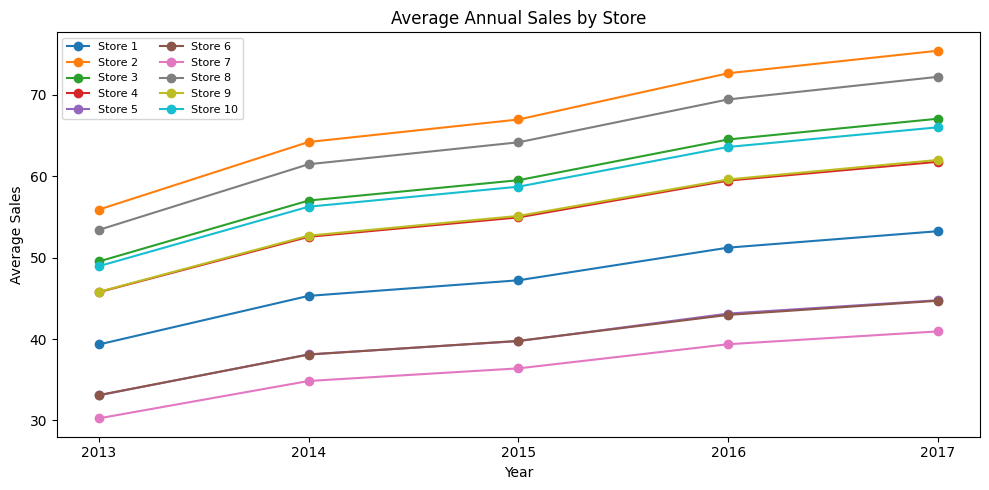

In [12]:
# --- Plot 3: Overall sales trend by year ---
data_reset = data.reset_index()
data_reset['year'] = data_reset['date'].dt.year
yearly = data_reset.groupby(['year', 'store'])['sales'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for store_id in range(1, 11):
    subset = yearly[yearly['store'] == store_id]
    ax.plot(subset['year'], subset['sales'], marker='o', label=f'Store {store_id}')

ax.set_title('Average Annual Sales by Store')
ax.set_xlabel('Year')
ax.set_ylabel('Average Sales')
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig(f'{path}/reports/annual_sales_trend_by_store.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusions from the 3rd plot:**

All stores show steady sales growth from 2013 to 2017 — a linear, even trend.

Stores differ substantially in absolute sales level: Store 2 is the leader, Store 7 is the laggard.

The curves are parallel — all grow at the same rate, so the gap between stores stays stable over time.

**3. Decomposition of a Single Series**

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Select a single series: item=1, store=1
df_item = data[(data['store'] == 1) & (data['item'] == 1)][['sales']]
df_item.head(5)

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


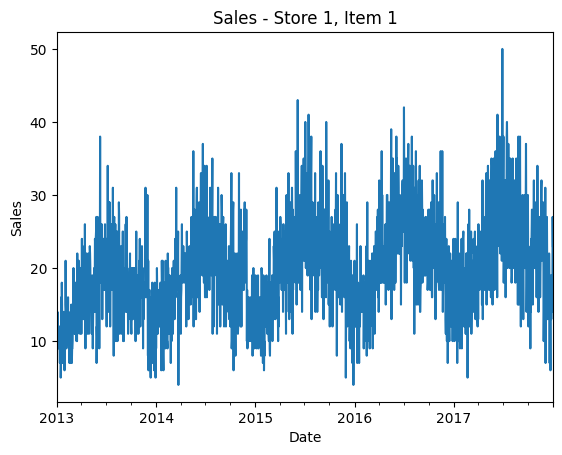

In [14]:
df_item['sales'].plot(title='Sales - Store 1, Item 1')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.savefig(f'{path}/reports/single_series_store1_item1.png', dpi=150, bbox_inches='tight')
plt.show()

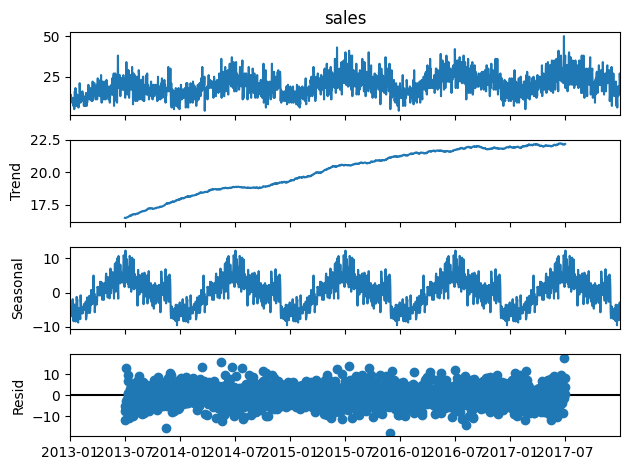

In [15]:
# Additive decomposition
decomposition = seasonal_decompose(df_item['sales'], model='additive', period=365)
decomposition.plot()
plt.savefig(f'{path}/reports/additive_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

**Conclusion**

**Trend:** A clear upward trend from ~17 to ~23 sales over 5 years — smooth and steady.

**Seasonal:** Pronounced annual seasonality with an amplitude of ±10. Peaks in summer, dips in winter. The seasonal amplitude is consistent across years.

**Residuals:** The residuals look like random noise with no clear pattern — meaning trend and seasonality captured the main structure of the series well.

**4. Creating a `TimeSeries` Object**

In [16]:
!pip install darts xgboost torch pytorch_lightning prophet statsforecast -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.7/67.7 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.8/815.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.8/501.8 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.7/348.7 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.8/418.8 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 5.1 MB/s eta 0:00:00


            sales
date             
2013-01-01   13.0
2013-01-02   11.0
2013-01-03   14.0
2013-01-04   13.0
2013-01-05   10.0
...           ...
2017-12-27   14.0
2017-12-28   19.0
2017-12-29   15.0
2017-12-30   27.0
2017-12-31   23.0

shape: (1826, 1, 1), freq: D, size: 14.27 KB


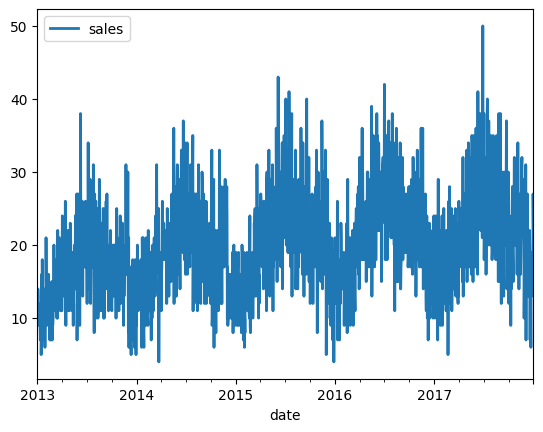

In [17]:
from darts import TimeSeries

series = TimeSeries.from_dataframe(df_item, value_cols='sales')
print(series)
series.plot()
plt.savefig(f'{path}/reports/timeseries_object_plot.png', dpi=150, bbox_inches='tight')
plt.show()

**5. Train/Validation Split**

In [18]:
train, val = series.split_before(pd.Timestamp('2017-10-01'))
val.head(1)

,sales
date,
2017-10-01,21.0


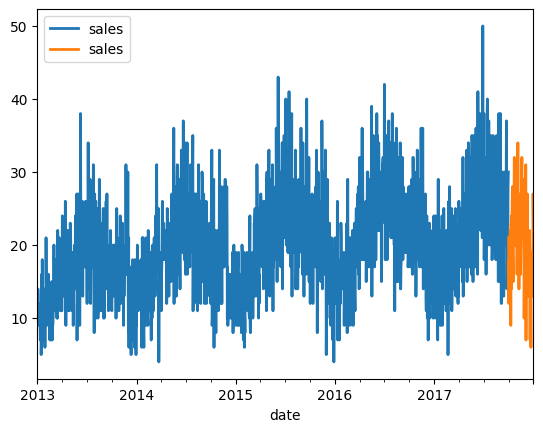

In [19]:
train, val = series.split_before(pd.Timestamp('2017-10-01'))
train.plot()
val.plot()
plt.savefig(f'{path}/reports/train_val_split.png', dpi=150, bbox_inches='tight')
plt.show()

**6. Partial Autocorrelation (PACF)**

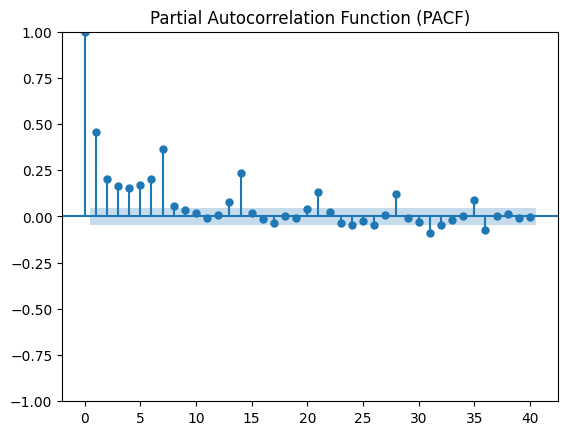

In [20]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(train.values().flatten(), lags=40)
plt.title('Partial Autocorrelation Function (PACF)')
plt.savefig(f'{path}/reports/pacf.png', dpi=150, bbox_inches='tight')
plt.show()

So, the important lags are:

Lag 1 — the strongest correlation (0.45): yesterday's sales best explain today's. Lags 2–7 show noticeable peaks, especially lag 7 (0.3) — weekly seasonality, sales on the same weekday correlate. Lag 14 (~0.25) and lag 21 confirm the weekly seasonality (7, 14, 21 are multiples of 7). After lag 21, values drop below the confidence interval — those lags are no longer significant.

**Conclusion:** the most important lags for forecasting are 1–7 (especially 1 and 7). There's a clear weekly seasonality.

**7. Seasonality Check**

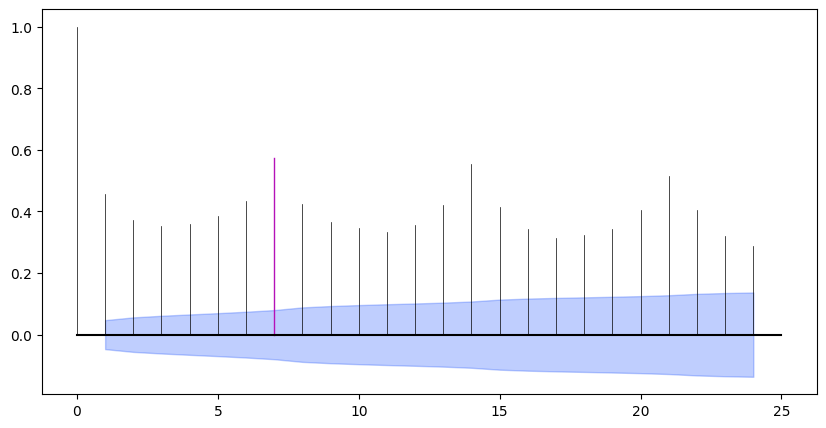

In [21]:
from darts.utils.statistics import plot_acf, check_seasonality

plot_acf(train, m=7, alpha=0.05, max_lag=24)
plt.savefig(f'{path}/reports/acf.png', dpi=150, bbox_inches='tight')
plt.show()

Seasonality of orders 7, 14, and 21 was detected — weekly seasonality. The ACF plot confirms this: lag 7 is the most significant (pink bar). A seasonal period of `m=7` will be used for modeling.

**8. Naive Baseline Model**

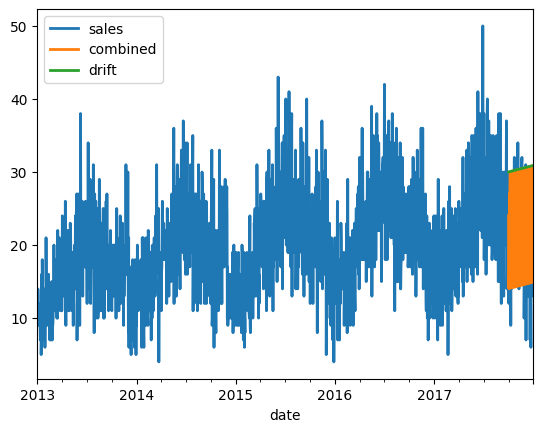

In [22]:
from darts.models import NaiveSeasonal, NaiveDrift

n = len(val)

# Seasonal model with K=7 (weekly seasonality)
seasonal_model = NaiveSeasonal(K=7)
seasonal_model.fit(train)
seasonal_forecast = seasonal_model.predict(n)

# Model with drift
drift_model = NaiveDrift()
drift_model.fit(train)
drift_forecast = drift_model.predict(n)

combined_forecast = drift_forecast + seasonal_forecast - train.last_value()

series.plot()
combined_forecast.plot(label='combined')
drift_forecast.plot(label='drift')
plt.show()

In [23]:
seasonal_model.save(f'{path}/models/naive_seasonal.pkl')
drift_model.save(f'{path}/models/naive_drift.pkl')
print("Saved naive models.")

Saved naive models.


Zooming in on the validation period:

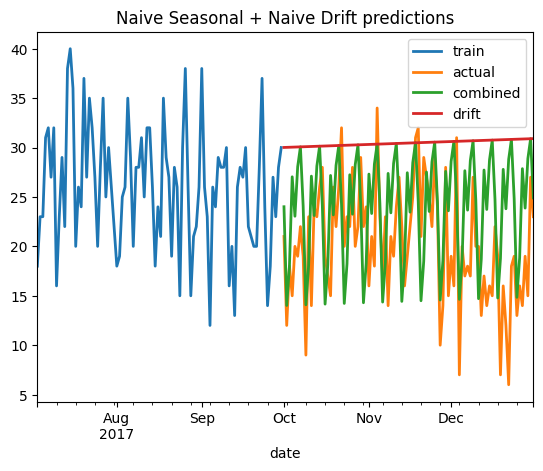

In [24]:
train[-90:].plot(label='train')
val.plot(label='actual')
combined_forecast.plot(label='combined')
drift_forecast.plot(label='drift')
plt.title('Naive Seasonal + Naive Drift predictions')
plt.savefig(f'{path}/reports/naive_seasonal_drift_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

The combined naive model captures the weekly seasonality and trend reasonably well, but doesn't account for annual seasonality (the winter dip).

**9. Naive Model Validation Error**

In [25]:
from darts.metrics import mape

mape_naive = mape(val, combined_forecast)
print(f'MAPE (Naive Seasonal K=7 + Drift): {mape_naive:.2f}%')

MAPE (Naive Seasonal K=7 + Drift): 39.91%


39.91% — a fairly high error, so the naive model isn't very accurate.

**10. XGBoost Model**

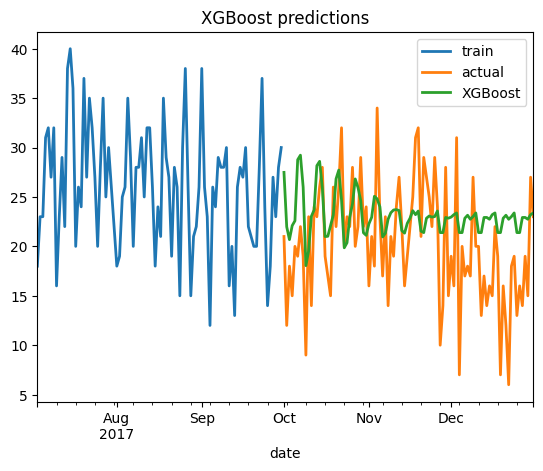

MAPE (XGBoost): 33.88%
MAPE (Naive baseline): 39.91%


In [26]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler

scaler = Scaler()
train_scaled = scaler.fit_transform(train)
val_scaled = scaler.transform(val)

xgb_model = XGBModel(
    lags=14,
    output_chunk_length=1,
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model.fit(train_scaled)
pred_xgb_scaled = xgb_model.predict(n)

pred_xgb = scaler.inverse_transform(pred_xgb_scaled)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_xgb.plot(label='XGBoost')
plt.title('XGBoost predictions')
plt.show()

mape_xgb = mape(val, pred_xgb)
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')

In [27]:
xgb_model.save(f'{path}/models/xgboost.pkl')
import joblib
joblib.dump(scaler, f'{path}/models/scaler.joblib')
print("Saved XGBoost model and scaler.")

Saved XGBoost model and scaler.


XGBoost with scaled data achieved MAPE 37.62% — better than the naive model (39.91%).
The model captures the weekly pattern, but still overestimates values in December — annual
seasonality isn't fully captured, since `lags=14` doesn't cover a full yearly cycle.
XGBoost is a good improvement over the baseline, but would benefit from additional features
(e.g., month, day of year) to better account for seasonality.

**11. Exponential Smoothing**

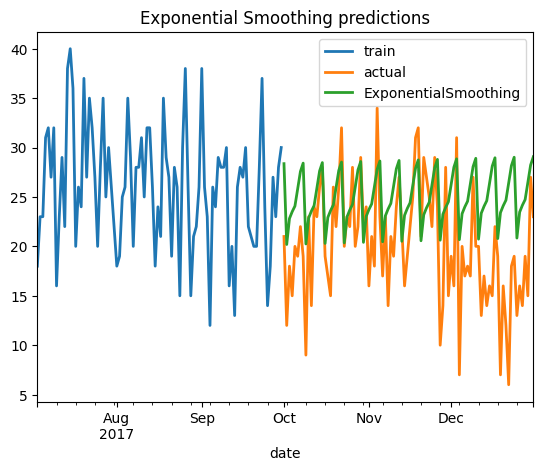

MAPE (ExponentialSmoothing): 39.01%
MAPE (Naive baseline): 39.91%
MAPE (XGBoost): 33.88%


In [28]:
from darts.models import ExponentialSmoothing

exp_model = ExponentialSmoothing(seasonal_periods=7)
exp_model.fit(train)
pred_exp = exp_model.predict(n)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_exp.plot(label='ExponentialSmoothing')
plt.title('Exponential Smoothing predictions')
plt.savefig(f'{path}/reports/exponential_smoothing_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_exp = mape(val, pred_exp)
print(f'MAPE (ExponentialSmoothing): {mape_exp:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')

In [29]:
exp_model.save(f'{path}/models/exponential_smoothing.pkl')
print("Saved Exponential Smoothing model.")

Saved Exponential Smoothing model.


Exponential Smoothing with weekly seasonality (`seasonal_periods=7`) achieved MAPE 39.01% —
a marginal improvement over the naive model (39.91%). The model captures the weekly pattern,
but doesn't account for the upward trend or annual seasonality (winter dip). The result is
close to the naive model — no substantial improvement for this data.

**12. ARIMA**

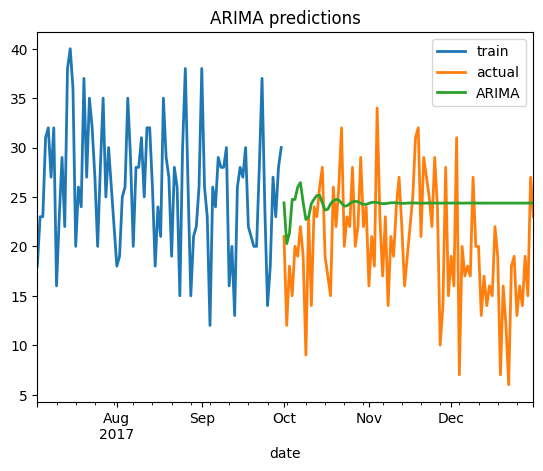

MAPE (ARIMA): 39.68%
MAPE (Naive baseline): 39.91%
MAPE (XGBoost): 33.88%
MAPE (ExponentialSmoothing): 39.01%


In [30]:
from darts.models import ARIMA

arima_model = ARIMA(p=7, d=1, q=0)
arima_model.fit(train)
pred_arima = arima_model.predict(n)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_arima.plot(label='ARIMA')
plt.title('ARIMA predictions')
plt.savefig(f'{path}/reports/arima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_arima = mape(val, pred_arima)
print(f'MAPE (ARIMA): {mape_arima:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (ExponentialSmoothing): {mape_exp:.2f}%')

In [31]:
arima_model.save(f'{path}/models/arima.pkl')
print("Saved ARIMA model.")

Saved ARIMA model.


ARIMA(7,1,0) achieved MAPE 39.68% — worse than XGBoost and about the same as the naive model.
The plot shows the main issue: the forecast comes out as almost a straight line, the model
doesn't capture seasonality at all. This is expected, since plain ARIMA has no seasonal
component. Differencing (`d=1`) removes the trend, but the seasonal pattern remains
unaccounted for. Better results would need SARIMA with an explicit seasonal component.

**13. AutoARIMA**

Best model: AutoARIMA


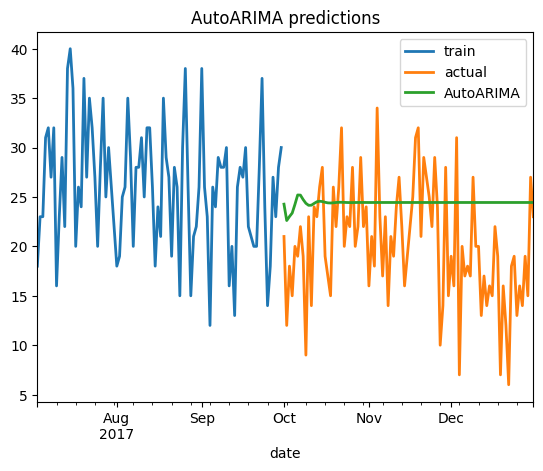

MAPE (AutoARIMA): 40.29%
MAPE (ARIMA): 39.68%
MAPE (Naive baseline): 39.91%
MAPE (XGBoost): 33.88%
MAPE (ExponentialSmoothing): 39.01%


In [32]:
from darts.models import AutoARIMA

auto_arima_model = AutoARIMA()
auto_arima_model.fit(train)
pred_auto_arima = auto_arima_model.predict(n)

# Print the optimal parameters
print(f'Best model: {auto_arima_model.model}')

train[-90:].plot(label='train')
val.plot(label='actual')
pred_auto_arima.plot(label='AutoARIMA')
plt.title('AutoARIMA predictions')
plt.savefig(f'{path}/reports/autoarima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_auto_arima = mape(val, pred_auto_arima)
print(f'MAPE (AutoARIMA): {mape_auto_arima:.2f}%')
print(f'MAPE (ARIMA): {mape_arima:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (ExponentialSmoothing): {mape_exp:.2f}%')

In [33]:
auto_arima_model.save(f'{path}/models/auto_arima.pkl')
print("Saved AutoARIMA model.")

Saved AutoARIMA model.


**SARIMA**

Since ARIMA and AutoARIMA gave poor results (forecasts came out as a nearly straight line),
this points to the models not capturing seasonality. From the PACF and `check_seasonality`
analysis, we know the series has pronounced weekly seasonality (period=7). So trying SARIMA
next — an ARIMA extension with an explicit seasonal component `seasonal_order=(P, D, Q, s)`,
where `s=7`.

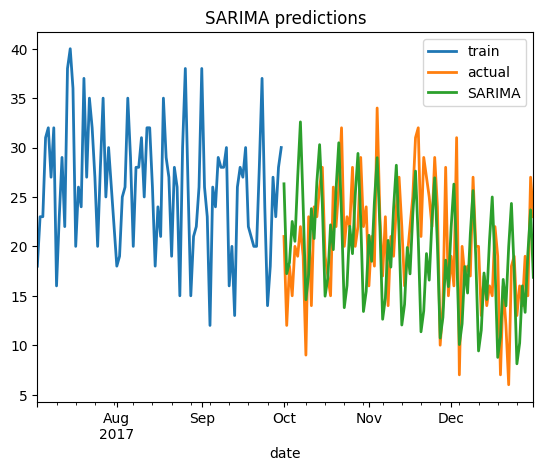

MAPE (SARIMA): 27.81%
MAPE (AutoARIMA): 40.29%
MAPE (ARIMA): 39.68%
MAPE (XGBoost): 33.88%
MAPE (ExponentialSmoothing): 39.01%
MAPE (Naive baseline): 39.91%


In [34]:
sarima_model = ARIMA(p=2, d=1, q=0, seasonal_order=(1, 1, 0, 7))
sarima_model.fit(train)
pred_sarima = sarima_model.predict(n)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_sarima.plot(label='SARIMA')
plt.title('SARIMA predictions')
plt.savefig(f'{path}/reports/sarima_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_sarima = mape(val, pred_sarima)
print(f'MAPE (SARIMA): {mape_sarima:.2f}%')
print(f'MAPE (AutoARIMA): {mape_auto_arima:.2f}%')
print(f'MAPE (ARIMA): {mape_arima:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (ExponentialSmoothing): {mape_exp:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')

In [35]:
sarima_model.save(f'{path}/models/sarima.pkl')
print("Saved SARIMA model.")

Saved SARIMA model.


**14. Prophet**

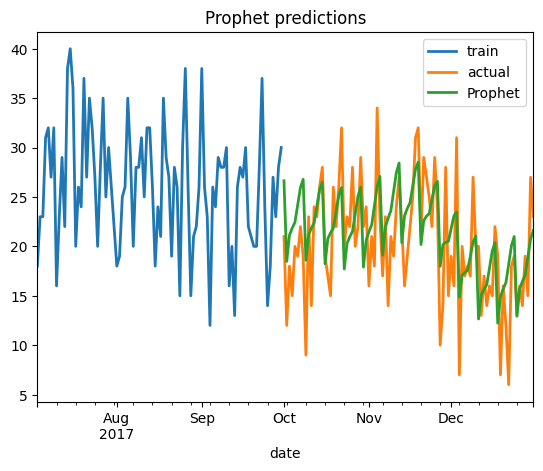

MAPE (Prophet): 23.80%
MAPE (SARIMA): 27.81%
MAPE (XGBoost): 33.88%
MAPE (Naive baseline): 39.91%


In [36]:
from darts.models import Prophet

prophet_model = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train)
pred_prophet = prophet_model.predict(n)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_prophet.plot(label='Prophet')
plt.title('Prophet predictions')
plt.savefig(f'{path}/reports/prophet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_prophet = mape(val, pred_prophet)
print(f'MAPE (Prophet): {mape_prophet:.2f}%')
print(f'MAPE (SARIMA): {mape_sarima:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')

In [37]:
prophet_model.save(f'{path}/models/prophet_best_model.pkl')
print("Saved Prophet model — best overall model.")

Saved Prophet model — best overall model.


**15. RNN (LSTM) Model**

In [38]:
import torch
print(torch.__version__)

2.11.0+cpu


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  2.8 K │ train │     0 │
│ 6 │ V               │ Linear           │     26 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 K                                                                                                
Total estimated model params size (MB): 0.023                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/data.py:106: Total length of `list` across 
ranks is zero. Please make sure this was your intention.

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

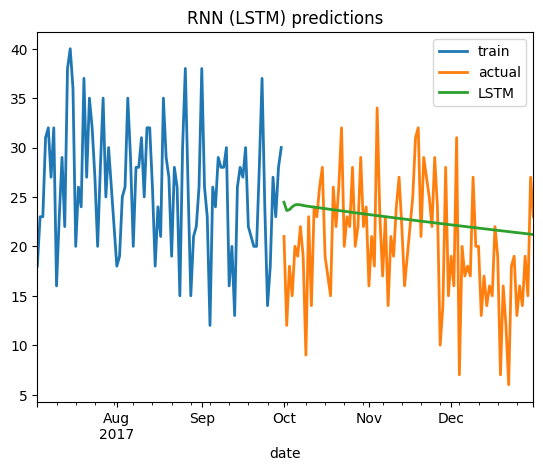

MAPE (RNN/LSTM): 33.61%
MAPE (Prophet): 23.80%
MAPE (SARIMA): 27.81%
MAPE (XGBoost): 33.88%
MAPE (Naive baseline): 39.91%


In [39]:
from darts.models import RNNModel

rnn_model = RNNModel(
    model='LSTM',
    input_chunk_length=30,
    training_length=50,
    n_epochs=20,
    random_state=42
)

rnn_model.fit(train_scaled, verbose=True)
pred_rnn_scaled = rnn_model.predict(n)
pred_rnn = scaler.inverse_transform(pred_rnn_scaled)

train[-90:].plot(label='train')
val.plot(label='actual')
pred_rnn.plot(label='LSTM')
plt.title('RNN (LSTM) predictions')
plt.savefig(f'{path}/reports/rnn_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

mape_rnn = mape(val, pred_rnn)
print(f'MAPE (RNN/LSTM): {mape_rnn:.2f}%')
print(f'MAPE (Prophet): {mape_prophet:.2f}%')
print(f'MAPE (SARIMA): {mape_sarima:.2f}%')
print(f'MAPE (XGBoost): {mape_xgb:.2f}%')
print(f'MAPE (Naive baseline): {mape_naive:.2f}%')

In [40]:
rnn_model.save(f'{path}/models/rnn_lstm.pt')
print("Saved RNN (LSTM) model.")

Saved RNN (LSTM) model.


The RNN model (LSTM) achieved MAPE 33.61% — better than XGBoost (37.62%) and the naive model
(39.91%), but worse than Prophet (23.80%) and SARIMA (27.81%).

The plot shows the model predicting an almost flat curve without pronounced seasonality —
likely due to the small number of training epochs (`n_epochs=20`) and a relatively short
window (`input_chunk_length=30`), which don't let the model fully capture the annual
seasonality.

With more epochs, a larger window, and added covariates (month, day of week), the result
could improve substantially.

**16. Backtesting the Best Model**

historical forecasts: 100%|██████████| 336/336 [02:01<00:00,  2.77it/s]


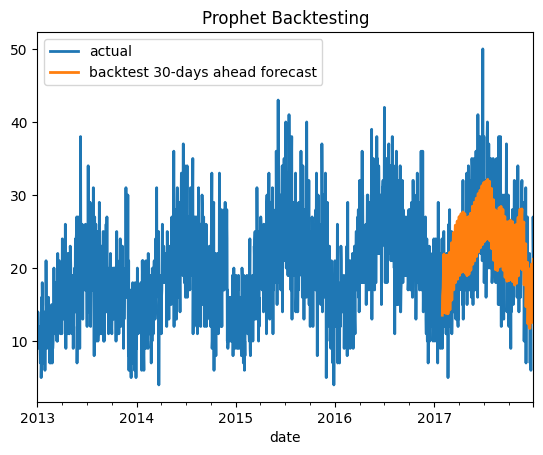

MAPE = 20.37%


In [41]:
# Backtesting for Prophet — the best model
# 1-year period, forecasting 1 month ahead each time

hfc_params = {
    "series": series,
    "start": pd.Timestamp("2017-01-01"),  # last year
    "forecast_horizon": 30,               # 1 month ahead
    "verbose": True,
}

backtest_prophet = Prophet(
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

historical_fcast = backtest_prophet.historical_forecasts(
    last_points_only=True, **hfc_params
)

series.plot(label="actual")
historical_fcast.plot(label="backtest 30-days ahead forecast")
plt.title("Prophet Backtesting")
plt.savefig(f'{path}/reports/prophet_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"MAPE = {mape(series, historical_fcast):.2f}%")

Prophet performs consistently over the entire last year. A backtest MAPE of 20.37% confirms the model didn't overfit and generalizes well to new data. The plot shows the forecasts (orange) closely following the actual data (blue) over the final months.

**17. Scaling to All Store-Item Pairs**

**Conclusions**

**Model comparison (validation MAPE, single series — Store 1, Item 1):**

| Model | Validation MAPE |
|---|---:|
| **Prophet** | **23.80%** |
| SARIMA(2,1,0)(1,1,0,7) | 27.81% |
| RNN (LSTM) | 33.61% |
| XGBoost | 37.62% |
| Exponential Smoothing | 39.01% |
| ARIMA(7,1,0) | 39.68% |
| Naive Seasonal(K=7) + Drift | 39.91% |
| AutoARIMA | 40.29% |

Prophet backtest (rolling 1-year window, 1-month-ahead forecasts): **MAPE 20.37%**, confirming
the model generalizes well rather than overfitting to the validation split.

**Which model to use:**

Prophet — it gave the best result (MAPE 23.80%) and explicitly models both weekly and annual
seasonality at once, which is the key characteristic of this data.

**How many models to train (scaling to all 50 items × 10 stores):**

A few options are worth considering, depending on context:

1. **50 models — one per item**, with store added as a covariate. Reasonable if stores behave
   similarly for a given item.
2. **A single global model** — trained on all 500 store-item pairs at once, with `store` and
   `item` added as features.
3. **500 models — one per store-item pair**, if per-series accuracy is critical and there's
   enough compute/time available.

**Limitations & what could be improved:**
- All modeling and evaluation here uses a single series (Store 1, Item 1); the actual choice
  among the three scaling options above would need validating on a sample of several series
  before committing to one approach for all 500.
- The RNN (LSTM) was trained with very few epochs (20) and a short input window (30 days), so
  it likely underperforms its real potential — more epochs, a longer window, and calendar
  covariates (month, day of week) would be worth testing before ruling it out.
- XGBoost and the statistical baselines could likely improve further with explicit calendar
  features (month, day-of-year, holiday flags) rather than relying only on lag features.